In [25]:
%reload_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from syd import make_viewer, Viewer

from src.files import results_dir
from src.plotting import errorPlot
from src.iaf.source_population import SourcePopulationGabor, vonmises
from src.iaf.plotting import weights_to_gabor, create_gabor_grid

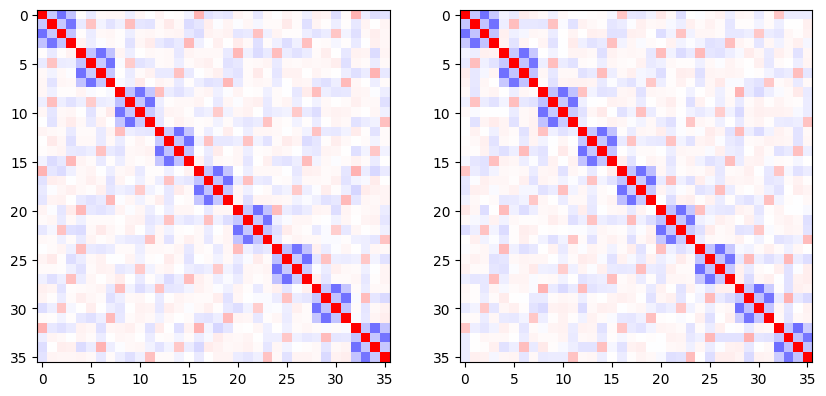

In [64]:
def _generate_random_center(source: SourcePopulationGabor, include_original: bool = False):
    stimori_original = source.generate_stimulus()
    stimori = stimori_original.copy()
    shift_vertical = np.random.randint(0, 3)
    shift_horizontal = np.random.randint(0, 3)
    stimori = np.roll(stimori, shift_vertical, axis=0)
    stimori = np.roll(stimori, shift_horizontal, axis=1)
    if include_original:
        return stimori, stimori_original
    return stimori

def generate_rates(num_samples, source: SourcePopulationGabor, with_random_center: bool = False):
    num_sources = 36
    rates = np.zeros((num_samples, num_sources))
    for sample in range(num_samples):
        if with_random_center:
            stimori = _generate_random_center(source)
            _rates = source.convert_stimulus_to_rates(stimori)
            rates[sample] = np.reshape(_rates, -1)
        else:
            rates[sample] = source.generate_rates()[0]

    return rates

edge_probability = 1.0  
concentration = 2
baseline_rate = 5
driven_rate = 45
tau_stim = 0.01
dt = 0.001
fixed_center = False

spg = SourcePopulationGabor(
    edge_probability=edge_probability,
    concentration=concentration,
    baseline_rate=baseline_rate,
    driven_rate=driven_rate,
    tau_stim=tau_stim,
    dt=dt,
    fixed_center=fixed_center,
)

num_samples = 2000
rates = generate_rates(num_samples, spg)
rates_no_center = generate_rates(num_samples, spg, with_random_center=True)

cov_rates = np.corrcoef(rates.T)
cov_rates_no_center = np.corrcoef(rates_no_center.T)

vrange = 1 # max(np.max(np.abs(cov_rates)), np.max(np.abs(cov_rates_no_center)))

plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(cov_rates, vmin=-vrange, vmax=vrange, cmap="bwr")
ax[1].imshow(cov_rates_no_center, vmin=-vrange, vmax=vrange, cmap="bwr")
plt.show()

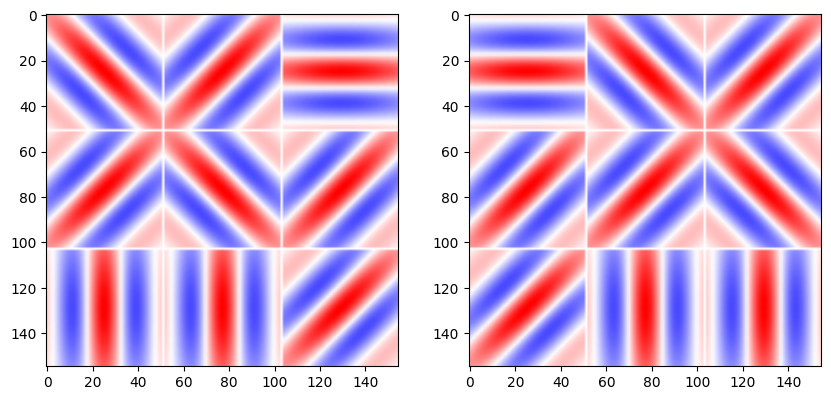

In [59]:
def generate_sample(spg: SourcePopulationGabor):
    stimori, original = _generate_random_center(spg, include_original=True)
    orientations = spg.orientations[stimori]
    orientations_original = spg.orientations[original]
    gabor = create_gabor_grid(orientations, spacing=1)[0]
    gabor_original = create_gabor_grid(orientations_original, spacing=1)[0]
    return gabor, gabor_original

gabor, original = generate_sample(spg)
plt.close('all')
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(gabor, vmin=-1, vmax=1, cmap="bwr", interpolation="bilinear")
ax[1].imshow(original, vmin=-1, vmax=1, cmap="bwr", interpolation="bilinear")
plt.show()
